<a href="https://colab.research.google.com/github/qbarger/byu-cs474/blob/master/lab7_style_transfer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/porterjenkins/byu-cs474/blob/master/lab7_style_transfer.ipynb)

# Style Transfer



In this lab, you will implement the style transfer algorithm proposed by [Gatys et. al. (2015)](https://arxiv.org/pdf/1508.06576.pdf). Your goal is to produce an image that has the high-level content of one image and the low-level style of another.

To perform style transfer, we will use a neural network as a feature extractor to determine style and content features, and we will optimize an image to reach a balance of the chosen style and content. Note that the network does not generate the final image, nor is the network trained at any point in this lab; instead of training network weights, we train the image itself. Through this lab, you will experience another way to use neural networks and see how deep learning can be used to optimize structures other than neural networks.



---

## Grading standards

Your code will be graded on the following:

* 20% Correct extraction of image statistics
* 35% Correct construction of loss function in a loss class
* 20% Plain English description of equations from (Gatys et. al. 2015) at the bottom of the notebook
* 15% Correct initialization and optimization of image variable
* 10% Awesome looking final image

---

Here's an additional example of style transfer:

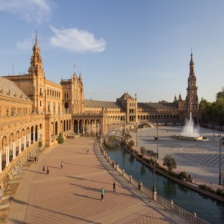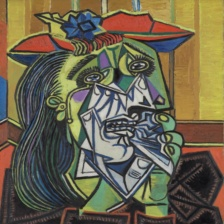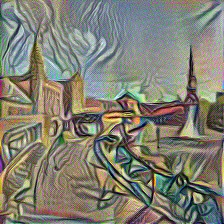

---

## Lab Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from tqdm import tqdm
from torch.nn.parameter import Parameter
from PIL import Image
import io

# IF NOT USING COLAB: comment out the following import statement:
from google.colab import files

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Select two images: one for content and one for style. The images should have noticeably different content and style from each other to make it clear if the style transfer worked.

In [2]:
# Use this code to upload your own images.
# NOTE: if you are not using Colab, `upload()` will not work. Just make sure the images are on your file system and set `content_path` and `style_path` accordingly.

load_and_normalize = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

def upload():
  print('Upload Content Image')
  file_dict = files.upload()
  content_path = io.BytesIO(file_dict[next(iter(file_dict))])

  print('\nUpload Style Image')
  file_dict = files.upload()
  style_path = io.BytesIO(file_dict[next(iter(file_dict))])
  return content_path, style_path

content_path, style_path = upload()

print("Content Path: {}".format(content_path))
print("Style Path: {}".format(style_path))


Upload Content Image


Saving horatii.jpg to horatii.jpg

Upload Style Image


Saving pollock.jpg to pollock.jpg
Content Path: <_io.BytesIO object at 0x7d3f816e0220>
Style Path: <_io.BytesIO object at 0x7d3f80fa06d0>


In [3]:
# Load in and normalize the images
content_image_orig = Image.open(content_path)
content_image = load_and_normalize(content_image_orig).unsqueeze(0).to(device)
style_image_orig = Image.open(style_path)
style_image = load_and_normalize(style_image_orig).unsqueeze(0).to(device)


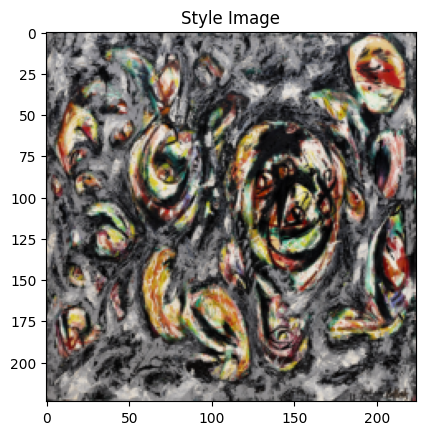

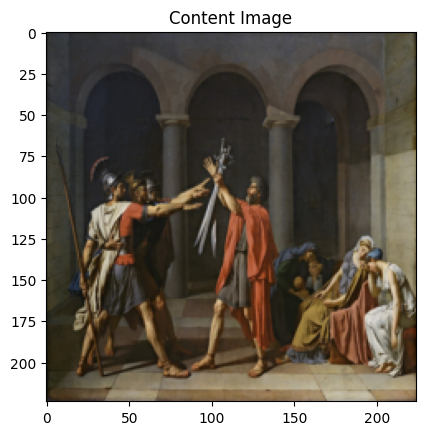

In [4]:
# Display the images
toPIL = transforms.ToPILImage()

def display(tensor, title=None):
    image = tensor.cpu().clone()
    image = image.squeeze(0)
    image = toPIL(image)
    plt.imshow(image)
    if title is not None:
        plt.title(title)
    plt.show()

plt.figure()
display(style_image, title='Style Image')

plt.figure()
display(content_image, title='Content Image')


___

## Part 1


We will use a pretrained VGG-16 network as a feature extractor to get the style and content statistics from the images.

We provide you with the `VGGIntermediate` class to load in the pretrained model and to grab intermediate layers.



* Correctly initialize a VGGIntermediate object to extract style and content
* Gather content statistics from the outputs of intermediate layers for the content image
* Gather style statistics for the style image

In [5]:
import torchvision.models as models

# You should not have to change any of the code in the following classes.

# Normalization layer normalizes the image pixels to mean=0 std=1 according to the statistics of the ImageNet training dataset (which the VGG was pretrained on)
class Normalization(nn.Module):
  def __init__(self):
      super(Normalization, self).__init__()
      self.mean = torch.tensor([0.485, 0.456, 0.406]).view(-1, 1, 1).to(device)
      self.std = torch.tensor([0.229, 0.224, 0.225]).view(-1, 1, 1).to(device)

  def forward(self, img):
      return (img - self.mean) / self.std

# Wrapper for the pretrained VGG-16. Instead of returning the output of the VGG, it returns the `requested` layers.
class VGGIntermediate(nn.Module):
  def __init__(self, requested=[]):
    super(VGGIntermediate, self).__init__()
    self.norm = Normalization().eval()
    self.intermediates = {}
    self.vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1).features.eval()
    for i, m in enumerate(self.vgg.children()):
        if isinstance(m, nn.ReLU):   # we want to set the relu layers to NOT do the relu in place.
          m.inplace = False          # the model has a hard time going backwards on the in place functions.

        if i in requested:
          # This stores the output of the requested layer as `intermediates[i]`
          def curry(i):
            def hook(module, input, output):
              self.intermediates[i] = output
            return hook
          m.register_forward_hook(curry(i))

  def forward(self, x):
    self.vgg(self.norm(x))
    return self.intermediates.copy()

We provide you with the list of VGG-16 layer names. Select the names of the layers you'd like to use to extract the content and style ([Gatys et. al. (2016)](https://arxiv.org/pdf/1508.06576.pdf) has suggestions on which layers to use on pages 3 and 12).

Save the layer indexes (not names) into a list for the `requested` parameter of `VGGIntermediate`.

In [6]:
vgg_names = ["conv1_1", "relu1_1", "conv1_2", "relu1_2", "maxpool1", "conv2_1", "relu2_1", "conv2_2", "relu2_2", "maxpool2", "conv3_1", "relu3_1", "conv3_2", "relu3_2", "conv3_3", "relu3_3","maxpool3", "conv4_1", "relu4_1", "conv4_2", "relu4_2", "conv4_3", "relu4_3","maxpool4", "conv5_1", "relu5_1", "conv5_2", "relu5_2", "conv5_3", "relu5_3","maxpool5"]

In [7]:
vgg_indexes = [0, 5, 10, 17, 19, 24]

Create a `VGGIntermediate` object, providing it with the intermediate layers. You can use a single network to extract both the content and the style, but be sure to keep track of which layers are which.

In [8]:
style_layers = [0, 5, 10, 17, 24]
content_layers = [19]

requested_layers = style_layers + content_layers

vgg = VGGIntermediate(requested=requested_layers).to(device).eval()

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:05<00:00, 95.0MB/s]


Use your `VGGIntermediate` network to extract the content from `content_image` and the style from `style_image`. Save these tensors: they will be used throughout training! Be sure to detach these tensors, since these are our labels and we don't want to backpropagate with respect to them.

In [9]:
content_features = vgg(content_image)
style_features = vgg(style_image)

content_targets = {
    layer: content_features[layer].detach()
    for layer in content_layers
}
style_targets = {
    layer: style_features[layer].detach()
    for layer in style_layers
}

---

## Part 2



The loss functions are key to learning the correct behavior in any machine learning problem. For style transfer, we have two losses: content loss and style loss. Our final loss is a combination of both to provide a balance between these competing objectives.

Show that you understand style transfer by describing the key equations of [Gatys et al. 2016](https://arxiv.org/pdf/1508.06576.pdf) in your own words. You may need to read the surrounding sections to understand the equations.

Content Loss:

- Describe equation (1) on p. 10 of (Gatys 2016) in plain English. Include the meaning of all variables and what each dimension represents for each matrix and vector variable.

$\mathcal{L}_{content}(\vec{p}, \vec{x}, l) = \frac{1}{2}\sum_{i,j} (F^l_{ij} - P^l_{ij})^2$

Content Loss is the mean-squared error between the feature maps of the original image and the feature maps of the generated image. L is the content reconstruction of p, the original image, and x, the generated image, at layer l. F is the activation of the i filter at position j in the layer l in the generated image. This is a specific activation for a feature. P is the same thing but in the original image. We then take the mean-squared error of those. This helps the generated image produce the same activations as the original image.

Style Loss:

- Describe equation (3) on p. 11 of (Gatys 2016) in plain English, including the meaning of all variables and what each dimension represents for each matrix and vector variable (including the output).

$G^l_{ij} = \sum_k F^l_{ik} F^l_{jk}$

Instead of using specific feature maps, style loss uses feature correlations. In order to see these correlations and build a style representation we compute a Gram matrix, G. For each response, k, we flatten the spatial extend (or vectorize it) which is what each F represents. Then we take the inner product between the vectorised feature map i and j in layer l to get the Gram matrix G.


- Describe equation (4) on p. 11 of (Gatys 2016) in plain English, including the meaning of all variables and what each dimension represents for each matrix and vector variable.

$E_l = \frac{1}{4N_l^2M_l^2} \sum_{i,j} (G^l_{ij} - A^l_{ij})^2$

This equation finds the style loss at layer, l. We use G, which is the Gram matrix of the generated image in layer l, and A, which is the same thing but for the original image. We minimize the mean-squared loss of these two variables. N is the channel size of the layer and M is the spatial size of the layer (Height and Width). We use these to normalize the loss so that bigger layers won't dominate the loss.





- Describe equation (5) on p. 11 of (Gatys 2016) in plain English, including the meaning of all variables and subscripts.

$\mathcal{L}_{style}(\vec{a}, \vec{x}) = \sum^L_{l=0} w_lE_l$

This equation is just applying the corresponding weight, w, to the style loss at each layer, El. This is to finish calculating the style loss over the total layers, L, between the original image, a, and the generated image, x.

___

## Part 3


Now that you understand the loss functions mathematically, create modules that calculate the content and style loss for a single content or style layer.

Since the targets will be static throughout learning (the content and style images don't change, nor the network), we can store them in the loss module objects, so we don't have to pass them into the forward each time.

In [10]:
# Produces a gram matrix from a 4D tensor input
def gram_matrix(F):
    B, C, H, W = F.shape

    # flatten
    F = F.view(B, C, H * W)

    # compute Gram matrix for each
    G = torch.bmm(F, F.transpose(1, 2))

    # normalize
    return G / (C * H * W)

# Represents the content loss function for a single content layer
class ContentLoss(nn.Module):
  # Since the targets don't change, store the targets in the init
  def __init__(self, target):
      super().__init__()
      self.target = target.detach()

  def forward(self, y_hat):
      loss = F.mse_loss(y_hat, self.target)
      return loss

# Represents the style loss function for a single style layer
class StyleLoss(nn.Module):
  def __init__(self, target):
      super().__init__()
      self.target = gram_matrix(target).detach()

  def forward(self, y_hat):
      G = gram_matrix(y_hat)
      loss = F.mse_loss(G, self.target)
      return loss


# Instantiate a content loss module for each content layer
#  with the content reference image outputs for that layer for comparison
content_losses = {
  layer: ContentLoss(content_targets[layer])
  for layer in content_layers
}

# Instantiate a style loss module for each style layer
#  with the style reference image outputs for that layer for comparison
style_losses = {
  layer: StyleLoss(style_targets[layer])
  for layer in style_layers
}



Now that you have a list of loss modules, write a loss function that computes the combined style transfer loss. You can weight the overall content and style losses, as well as weighting each layerwise loss value.

Return the combined loss as a tensor for learning. Return the content and style loss values for plotting.

In [16]:
def total_style_loss(features, content_losses, style_losses, content_weight, style_weight, content_layer_weights, style_layer_weights):
  content_loss = 0.0
  style_loss = 0.0

  # if no layer weights than set it to 1
  if content_layer_weights is None:
    content_layer_weights = {k: 1.0 for k in content_losses}

  if style_layer_weights is None:
    style_layer_weights = {k: 1.0 for k in style_losses}

  # content loss
  for layer, loss_module in content_losses.items():
    layer_loss = loss_module(features[layer])
    content_loss += content_layer_weights[layer] * layer_loss

  # style loss
  for layer, loss_module in style_losses.items():
    layer_loss = loss_module(features[layer])
    style_loss += style_layer_weights[layer] * layer_loss

  # total loss
  total_loss = content_weight * content_loss + style_weight * style_loss

  return total_loss, content_loss.item(), style_loss.item()

___

## Part 4

Create and run a method that minimizes the content and style loss for a copy of the content image

Note that the content loss should be zero if you take out the style loss. Why is that?

**TODO:**

* Use an Adam optimizer (try learning rate of .1, but feel free to experiment)
* Show both the content and the style loss every 50 steps
* Ensure that the outputs don't go out of range (clamp them)
* Display the tensor as an image!
* Experiment with different hyperparameters or network layers until you're satisfied with your final image


First, we need to define our image. While we can create a random image and hope that the optimization works, the best results come from using a clone of the content image. That way, the image starts with the desired content and the content loss only needs to preserve the existing content.

Create a clone of the content image as your initial "generated" image. Calculate and print content and style loss (separately) for your generated image. What do you notice about these losses? Make sure the losses match what you'd expect, given that the generated image is a copy of the content image.

In [38]:
generated_image = content_image.clone().requires_grad_(True)
features = vgg(generated_image)

# added this to match weighting in the article
style_layer_weights = {
    layer: 1 / len(style_layers)
    for layer in style_layers
}

# parameters
content_weight = 1
style_weight = 1e5
learning_rate = 0.05
num_steps = 1000

total_loss, content_loss, style_loss = total_style_loss(features, content_losses, style_losses, content_weight, style_weight, None, style_layer_weights)

print("Content loss: ", content_loss)
print("Style loss: ", style_loss)
print("Total loss: ", total_loss)

Content loss:  0.0
Style loss:  0.031156621873378754
Total loss:  tensor(3115.6621, device='cuda:0', grad_fn=<AddBackward0>)


Prepare your generated image for optimization. You need two things:


1.   Your generated image must require gradients: set requires_grad to true by setting the object parameter `requires_grad` or calling the function `requires_grad_()`.
2.   Create an optimizer with your generated image as the parameter. Torch optimizers expect a list of parameters (or tensors), so you'll need to wrap your generated image in a single-item list for the optimizer.



In [39]:
# Prepare your generated image to learn

# Create your optimizer: we suggest starting using an Adam optimizer with lr=.1
optimizer = torch.optim.Adam([generated_image], learning_rate)


Now create and run your training loop, storing content and style losses as you train. Remember, you will be optimizing the **generated image** according to the content and style statistics extracted with the network. Print your final image.

For best results, use `torch.clamp_(generated_im.data, 0, 1)` to keep your pixel values in range after each learning step.

Style transfer is very susceptible to overtraining, which introduces a lot of noise to the final image. Print your image often during the training process to find the best-looking image.

Step 0
Content Loss: 0.0
Style Loss: 0.031156621873378754


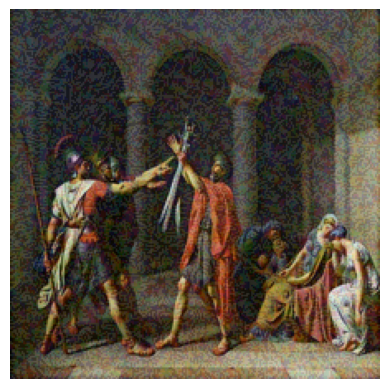

Step 50
Content Loss: 80.15856170654297
Style Loss: 0.0005851176101714373
Step 100
Content Loss: 58.067447662353516
Style Loss: 0.00028475976432673633


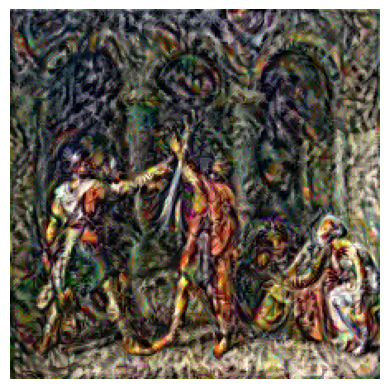

Step 150
Content Loss: 51.535709381103516
Style Loss: 0.00022940844064578414
Step 200
Content Loss: 48.72849655151367
Style Loss: 0.0002062440908048302


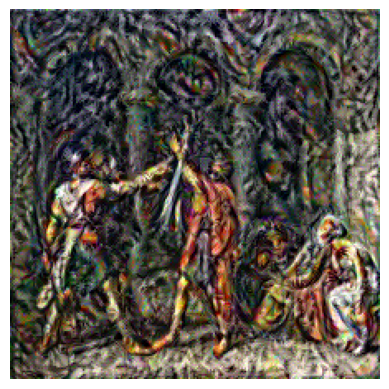

Step 250
Content Loss: 50.37033462524414
Style Loss: 0.0003564097569324076
Step 300
Content Loss: 44.72103500366211
Style Loss: 0.00019716736278496683


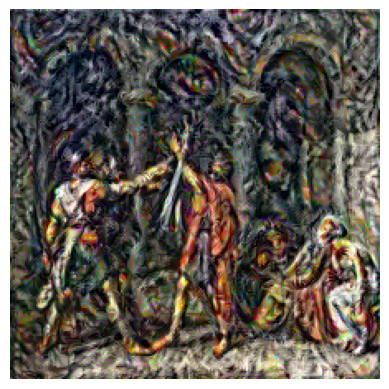

Step 350
Content Loss: 41.77145004272461
Style Loss: 0.00031366784241981804
Step 400
Content Loss: 48.100486755371094
Style Loss: 0.0002377042401349172


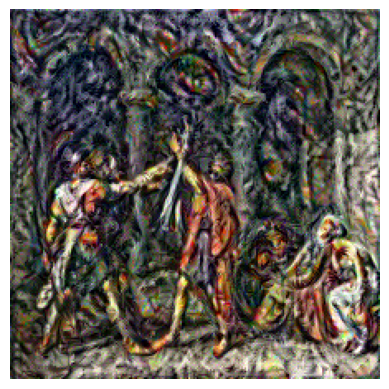

Step 450
Content Loss: 42.23775100708008
Style Loss: 0.00018402606656309217
Step 500
Content Loss: 39.93175506591797
Style Loss: 0.00016762586892582476


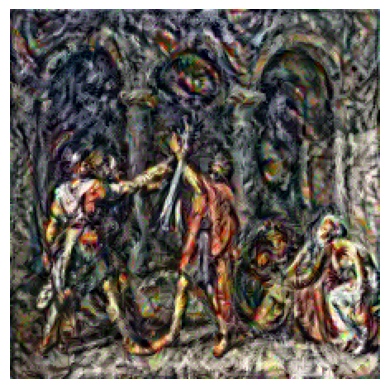

Step 550
Content Loss: 39.50236129760742
Style Loss: 0.00016813389083836228
Step 600
Content Loss: 72.42411804199219
Style Loss: 0.0022602039389312267


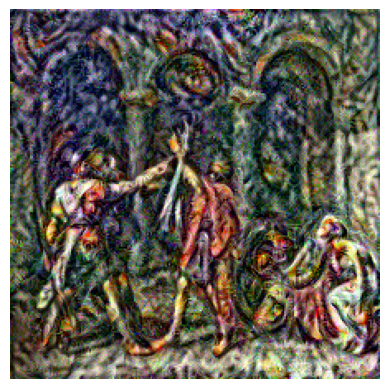

Step 650
Content Loss: 52.21631622314453
Style Loss: 0.0003310774336569011
Step 700
Content Loss: 43.357967376708984
Style Loss: 0.00019952758157160133


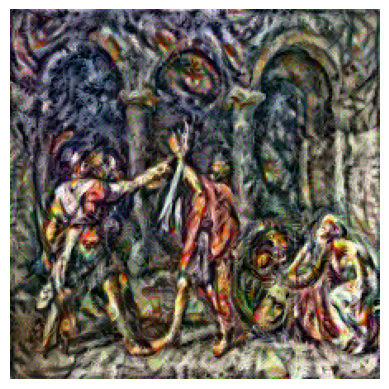

Step 750
Content Loss: 41.46546936035156
Style Loss: 0.00021548775839619339
Step 800
Content Loss: 39.37446212768555
Style Loss: 0.00016229276661761105


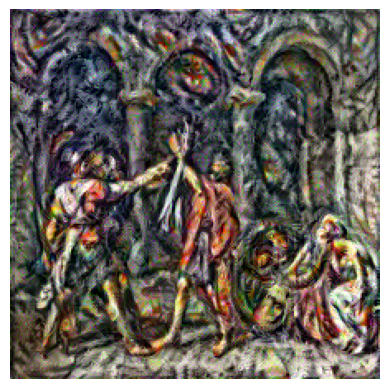

Step 850
Content Loss: 42.72554397583008
Style Loss: 0.00019100707140751183
Step 900
Content Loss: 38.64717483520508
Style Loss: 0.00016089084965642542


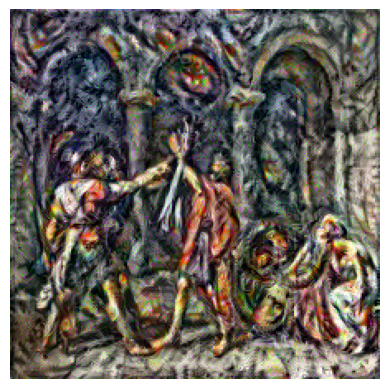

Step 950
Content Loss: 38.001731872558594
Style Loss: 0.00017182542069349438


In [40]:
content_history = []
style_history = []

def show_image(tensor):
  image = tensor.detach().cpu().squeeze(0)
  image = image.permute(1,2,0)
  plt.imshow(image)
  plt.axis("off")
  plt.show()

for step in range(num_steps):

  optimizer.zero_grad()

  # get features from generated image
  features = vgg(generated_image)

  total_loss, content_loss, style_loss = total_style_loss(
    features,
    content_losses,
    style_losses,
    content_weight,
    style_weight,
    None,
    style_layer_weights
  )

  total_loss.backward()

  optimizer.step()

  # clamp pixel values
  torch.clamp_(generated_image.data, 0, 1)

  content_history.append(content_loss)
  style_history.append(style_loss)

  # show losses every 50 steps
  if step % 50 == 0:
    print(f"Step {step}")
    print(f"Content Loss: {content_loss}")
    print(f"Style Loss: {style_loss}")

  if step % 100 == 0:
    show_image(generated_image)

Plot your content and style losses. Content loss should start at 0 and increase as style loss decreases. They should both reach an equilibrium.

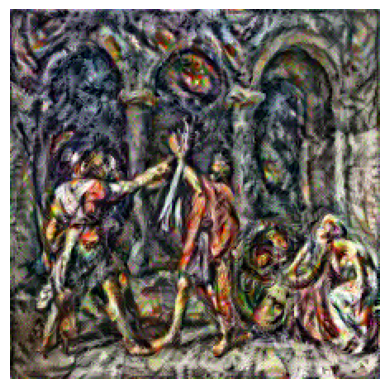

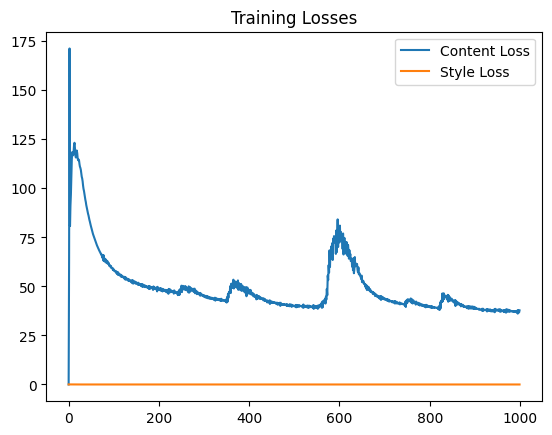

[0.0, 63.71564483642578, 171.3014678955078, 80.781005859375, 91.119873046875, 96.89923095703125, 105.1109390258789, 114.6912612915039, 118.46115112304688, 117.47815704345703, 116.82135009765625, 118.84138488769531, 122.05416870117188, 123.22369384765625, 120.46819305419922, 116.86026763916016, 115.7244644165039, 117.45193481445312, 119.2707748413086, 117.95358276367188, 115.33538055419922, 114.31414031982422, 114.75916290283203, 114.26429748535156, 112.41019439697266, 111.06221771240234, 110.42913818359375, 109.4325942993164, 107.5400390625, 105.94091796875, 105.04312896728516, 103.53968811035156, 101.314697265625, 99.68038177490234, 98.64381408691406, 97.04081726074219, 95.32249450683594, 94.1993637084961, 93.06785583496094, 91.51485443115234, 90.364013671875, 89.4591293334961, 88.12640380859375, 87.02516174316406, 86.17689514160156, 84.94123840332031, 83.91500091552734, 83.0345230102539, 81.92771911621094, 81.04000091552734, 80.15856170654297, 79.09696960449219, 78.32633209228516, 77

In [41]:
show_image(generated_image)
plt.plot(content_history, label="Content Loss")
plt.plot(style_history, label="Style Loss")
plt.legend()
plt.title("Training Losses")
plt.show()
print(content_history)

Now that you have style transfer working, the results may not look very appealing. Different content and style images require different hyperparameters, so you should play around with different network layers, learning rates, and loss weighting to get the best results.

I played around with the hyperparameters and I figured that setting the learning rate to 0.05 and the style weight to 1e5 helped to get the most satisfying picture. This slowed down the amount of change given to style. The style image is pretty strong, so with other values the style seemed to take over and you couldn't really tell the image very well. I found that the current values give a nice mix of being able to tell what's in the picture and recognizing the style.